<a href="https://colab.research.google.com/github/aryank2074-ai/ecommerce-shipping-delay-prediction/blob/main/Ecomm_Shipping_Prediction_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("Train (2).csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


## Observation
### 1.There is no data that is null or missing value.
### 2.Data consists of 10999 rows.
### 3.There doesn't seem to be a glaring issue with the data types of each column(it's appropriate).

In [ ]:
nums=df.select_dtypes(exclude="object")
cats=df.select_dtypes(include="object")
print(nums.columns)
print(cats.columns)

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')
Index(['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender'], dtype='object')


In [ ]:
df[nums.columns].describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [ ]:
df[cats.columns].describe()

,Warehouse_block,Mode_of_Shipment,Product_importance,Gender
count,10999,10999,10999,10999
unique,5,3,3,2
top,F,Ship,low,F
freq,3666,7462,5297,5545


In [ ]:
for col in cats:
    print("value count column {}:".format(col))
    print(df[col].value_counts())
    print()

value count column Warehouse_block:
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

value count column Mode_of_Shipment:
Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

value count column Product_importance:
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

value count column Gender:
Gender
F    5545
M    5454
Name: count, dtype: int64



# Univariate Analysis

In [ ]:
from matplotlib import rcParams

rcParams["figure.figsize"]=12,6
rcParams["lines.linewidth"]=3
rcParams["xtick.labelsize"]="x-large"
rcParams["ytick.labelsize"]="x-large"

### Box plots

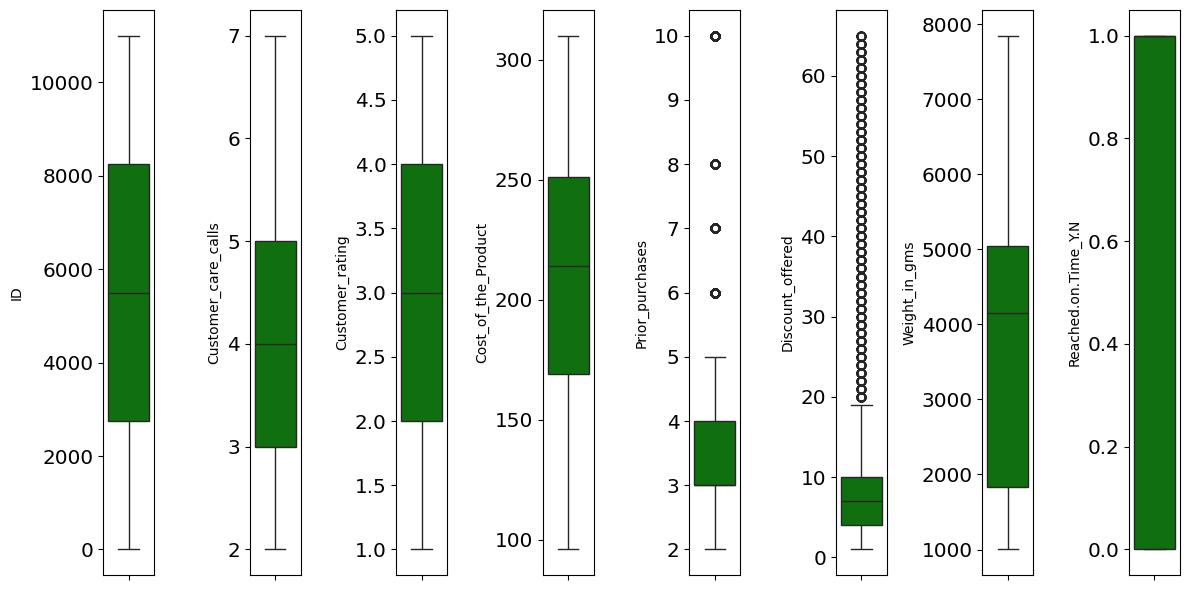

In [ ]:
features = nums.columns
for i in range(0,len(features)):
    plt.subplot(1,len(features),i+1)
    sns.boxplot(y=df[features[i]],color="green",orient="v")
    plt.tight_layout()

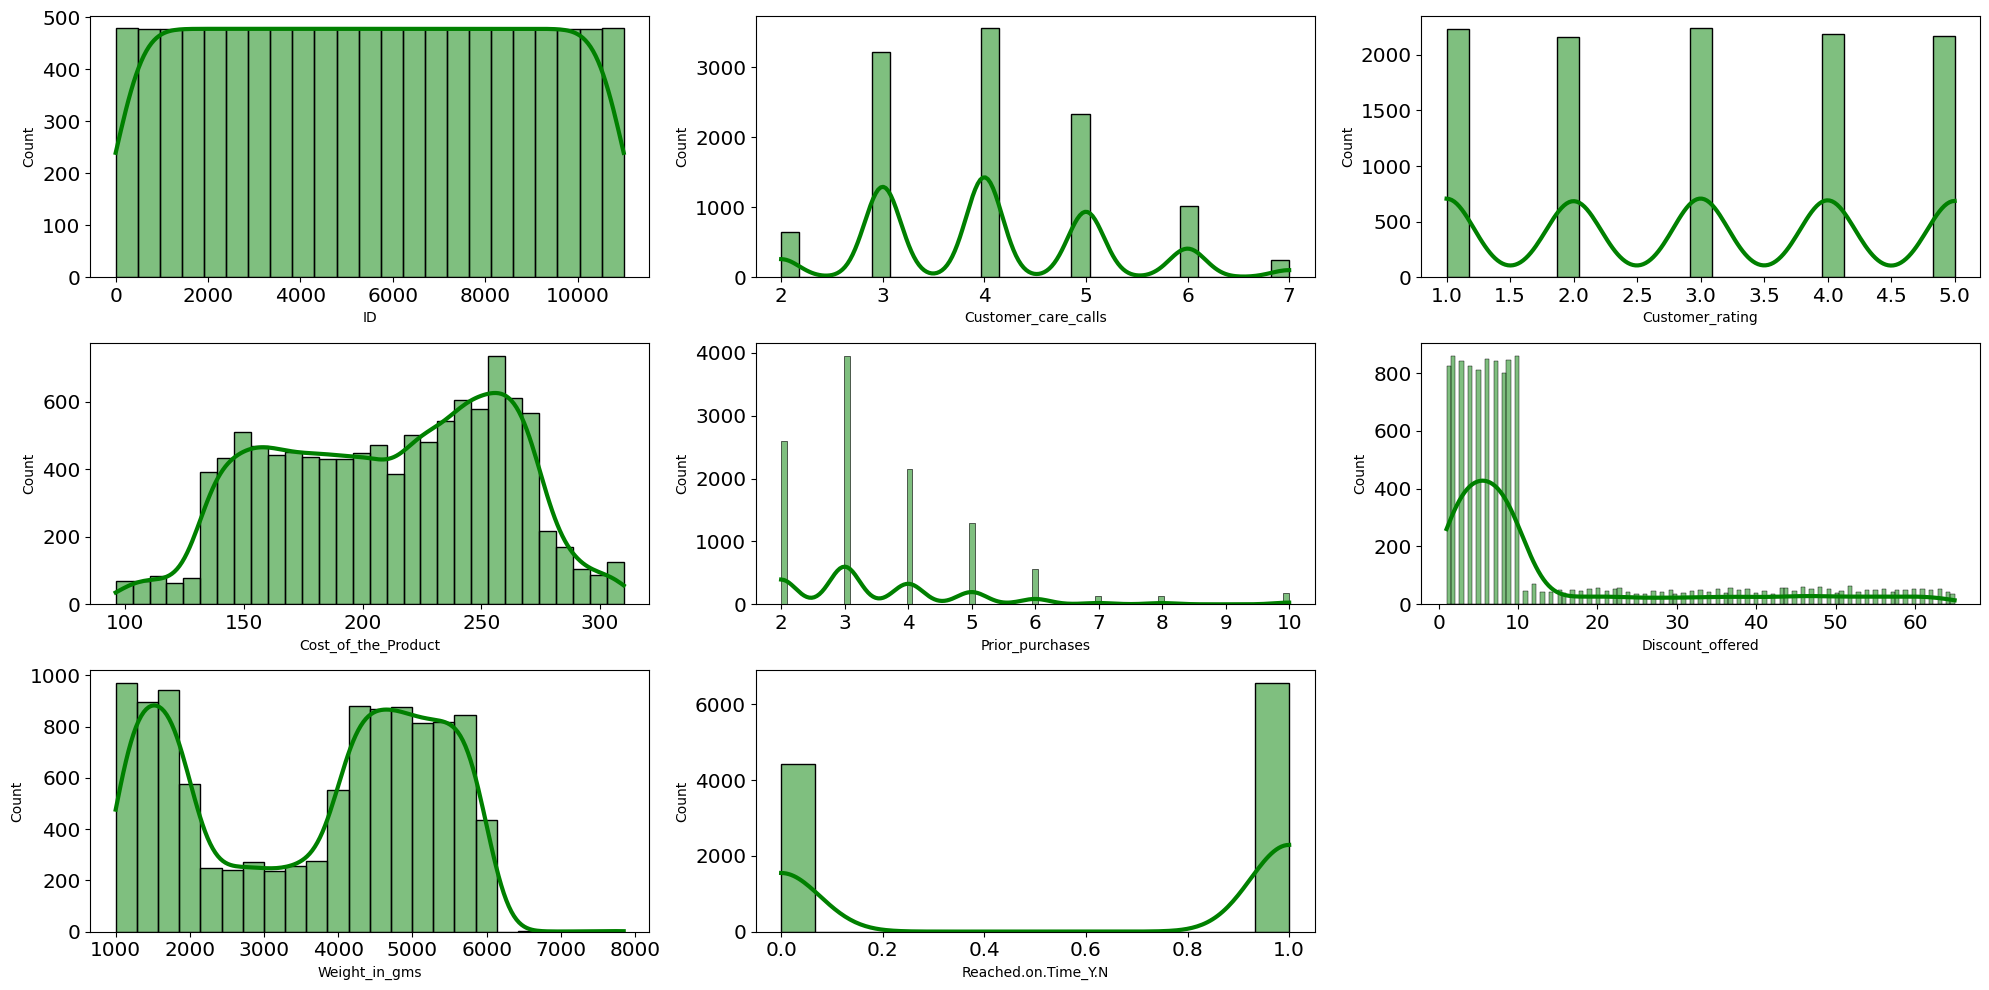

In [ ]:
features = nums.columns
plt.figure(figsize=(20,10))
for i in range(0,len(features)):
    plt.subplot(3,3,i+1)
    sns.histplot(x=df[features[i]],kde=True,color="green")
    plt.xlabel(features[i])
    plt.tight_layout()

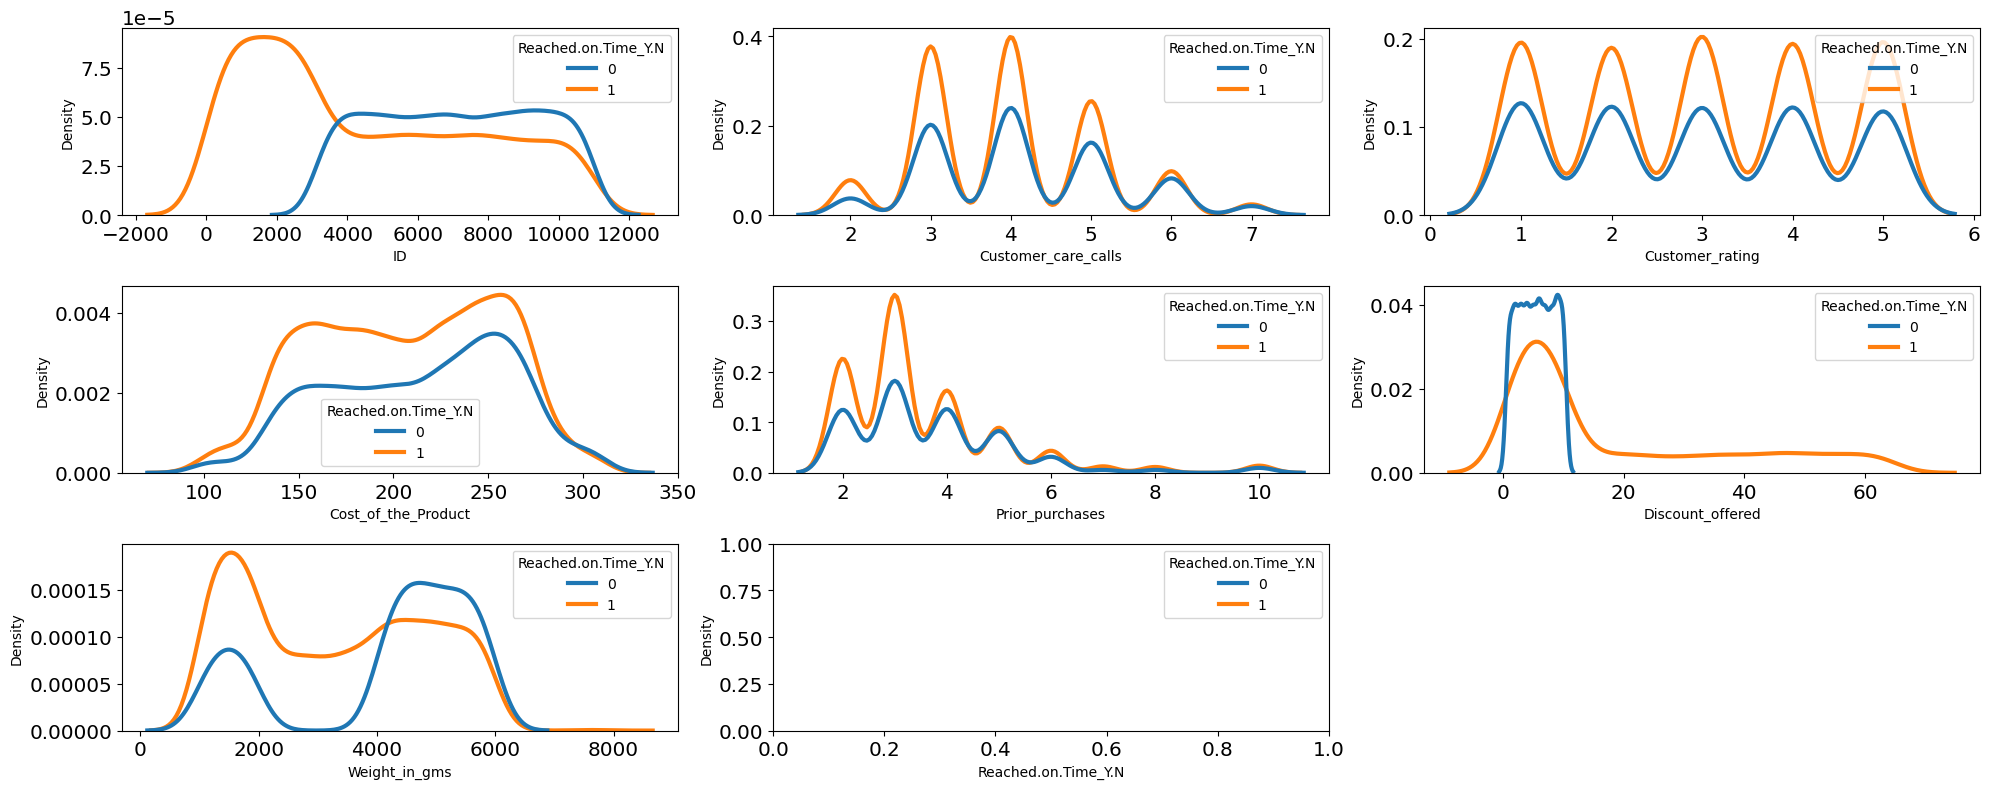

In [ ]:
features = nums.columns
plt.figure(figsize=(20,8))
for i in range(0,len(features)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(data=df,x=features[i],hue="Reached.on.Time_Y.N")
    plt.tight_layout()

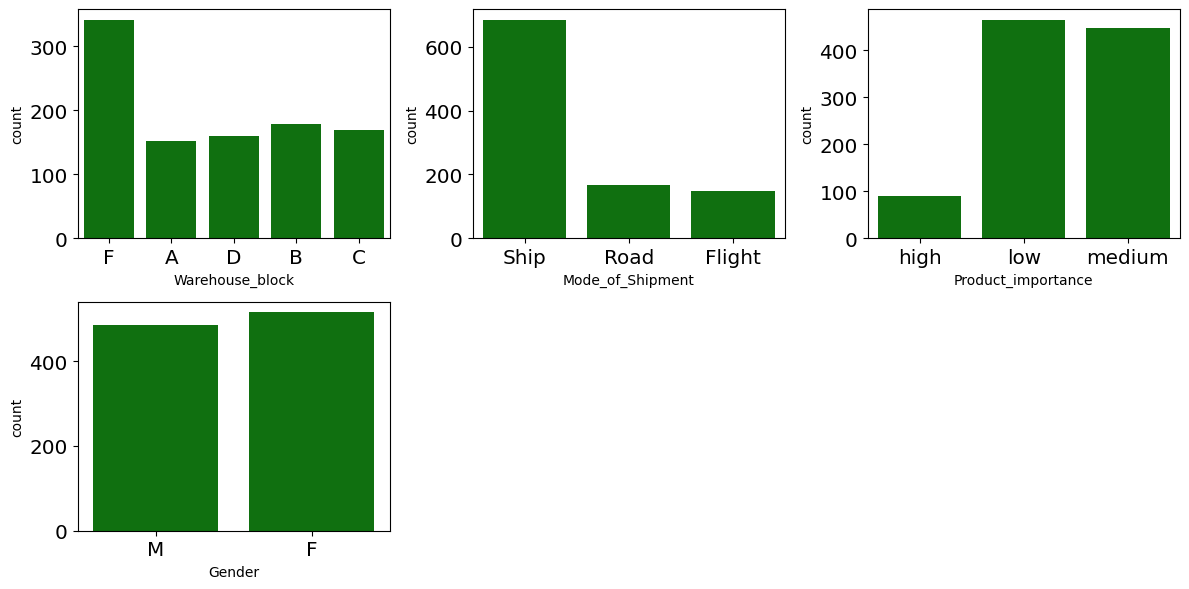

In [ ]:
# Categorical distrobution
df_samples=df.sample(1000,random_state=42)
for i in range(0,len(cats.columns)):
    plt.subplot(2,3,i+1)
    sns.countplot(x=df_samples[cats.columns[i]],color="green",orient="v")
    plt.tight_layout()

<Axes: >

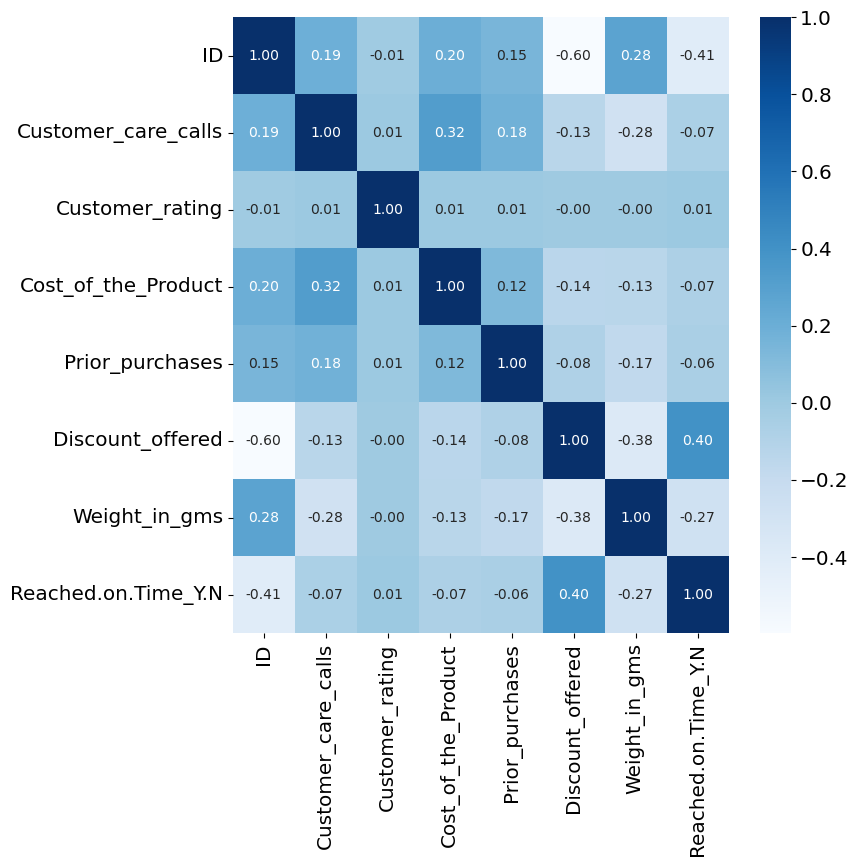

In [ ]:
# correlation heatmap
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True),cmap="Blues",annot=True,fmt=".2f")

# Catgorical columns vs Target Variable

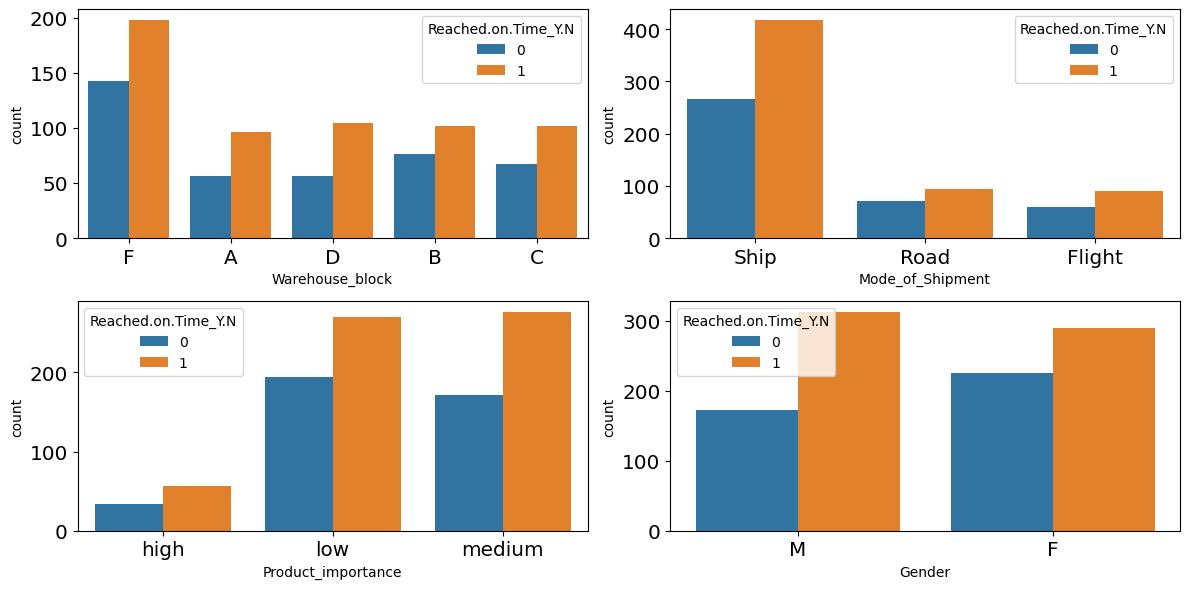

In [ ]:
features=cats.columns
for i in range(0,len(features)):
    plt.subplot(2,2,i+1)
    sns.countplot(data=df_samples,x=features[i],hue="Reached.on.Time_Y.N")
    plt.tight_layout()

# Insight and Visualization

In [ ]:
df_group1=df.groupby(["Reached.on.Time_Y.N","Mode_of_Shipment"]).agg({"ID":"nunique"}).reset_index()
df_group1

,Reached.on.Time_Y.N,Mode_of_Shipment,ID
0,0,Flight,708
1,0,Road,725
2,0,Ship,3003
3,1,Flight,1069
4,1,Road,1035
5,1,Ship,4459


In [ ]:
df_group2=df.groupby("Reached.on.Time_Y.N").agg({"ID":"nunique"}).reset_index()
df_group2

,Reached.on.Time_Y.N,ID
0,0,4436
1,1,6563


In [ ]:
df_group3=df_group1.merge(df_group2,on="Reached.on.Time_Y.N")
df_group3

,Reached.on.Time_Y.N,Mode_of_Shipment,ID_x,ID_y
0,0,Flight,708,4436
1,0,Road,725,4436
2,0,Ship,3003,4436
3,1,Flight,1069,6563
4,1,Road,1035,6563
5,1,Ship,4459,6563


In [ ]:
df_group4=df.groupby("Mode_of_Shipment").agg({"ID":"nunique"}).reset_index()
df_group4

,Mode_of_Shipment,ID
0,Flight,1777
1,Road,1760
2,Ship,7462


In [ ]:
df_group5=df_group1.merge(df_group4,on="Mode_of_Shipment")
df_group5

,Reached.on.Time_Y.N,Mode_of_Shipment,ID_x,ID_y
0,0,Flight,708,1777
1,0,Road,725,1760
2,0,Ship,3003,7462
3,1,Flight,1069,1777
4,1,Road,1035,1760
5,1,Ship,4459,7462


In [ ]:
df_group5["Ratio_Percentage(%)"]=df_group5["ID_x"]/df_group5["ID_y"]*100
df_group5.columns=["Late","Mode Shipment","UniqueCustomers","TotalUnique","Ratio_Percentage(%)"]
df_group5

,Late,Mode Shipment,UniqueCustomers,TotalUnique,Ratio_Percentage(%)
0,0,Flight,708,1777,39.842431
1,0,Road,725,1760,41.193182
2,0,Ship,3003,7462,40.243902
3,1,Flight,1069,1777,60.157569
4,1,Road,1035,1760,58.806818
5,1,Ship,4459,7462,59.756098


In [ ]:
df_group3["Ratio_Percentage(%)"]=df_group3["ID_x"]/df_group3["ID_y"]*100
df_group3.columns=["Late","Mode Shipment","UniqueCustomers","TotalUnique","Ratio_Percentage(%)"]
df_group3

,Late,Mode Shipment,UniqueCustomers,TotalUnique,Ratio_Percentage(%)
0,0,Flight,708,4436,15.960325
1,0,Road,725,4436,16.343553
2,0,Ship,3003,4436,67.696123
3,1,Flight,1069,6563,16.288283
4,1,Road,1035,6563,15.770227
5,1,Ship,4459,6563,67.941490


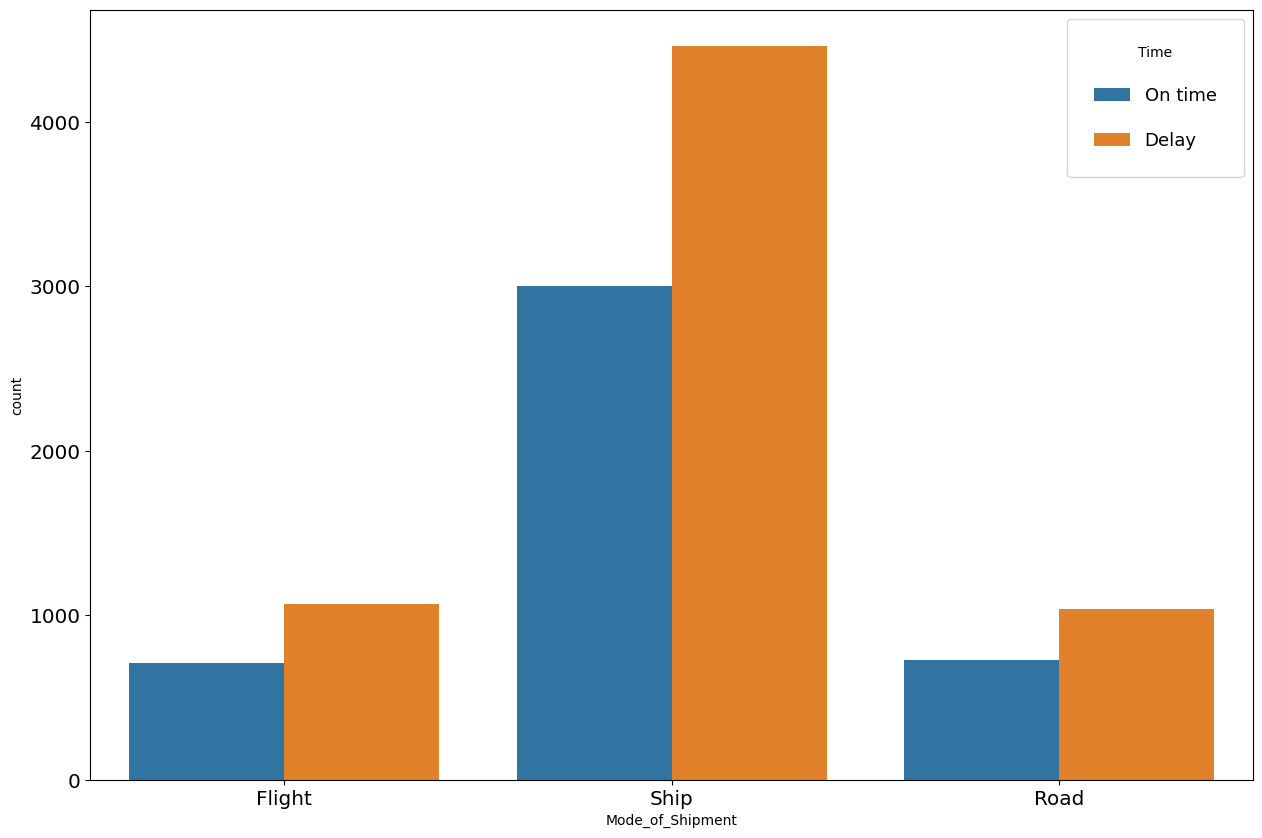

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=df,x="Mode_of_Shipment",hue="Reached.on.Time_Y.N")
plt.legend(loc="upper right",borderpad=1.5,labelspacing=1.5,fontsize=13,title="Time",
          labels=["On time","Delay"])
plt.show()

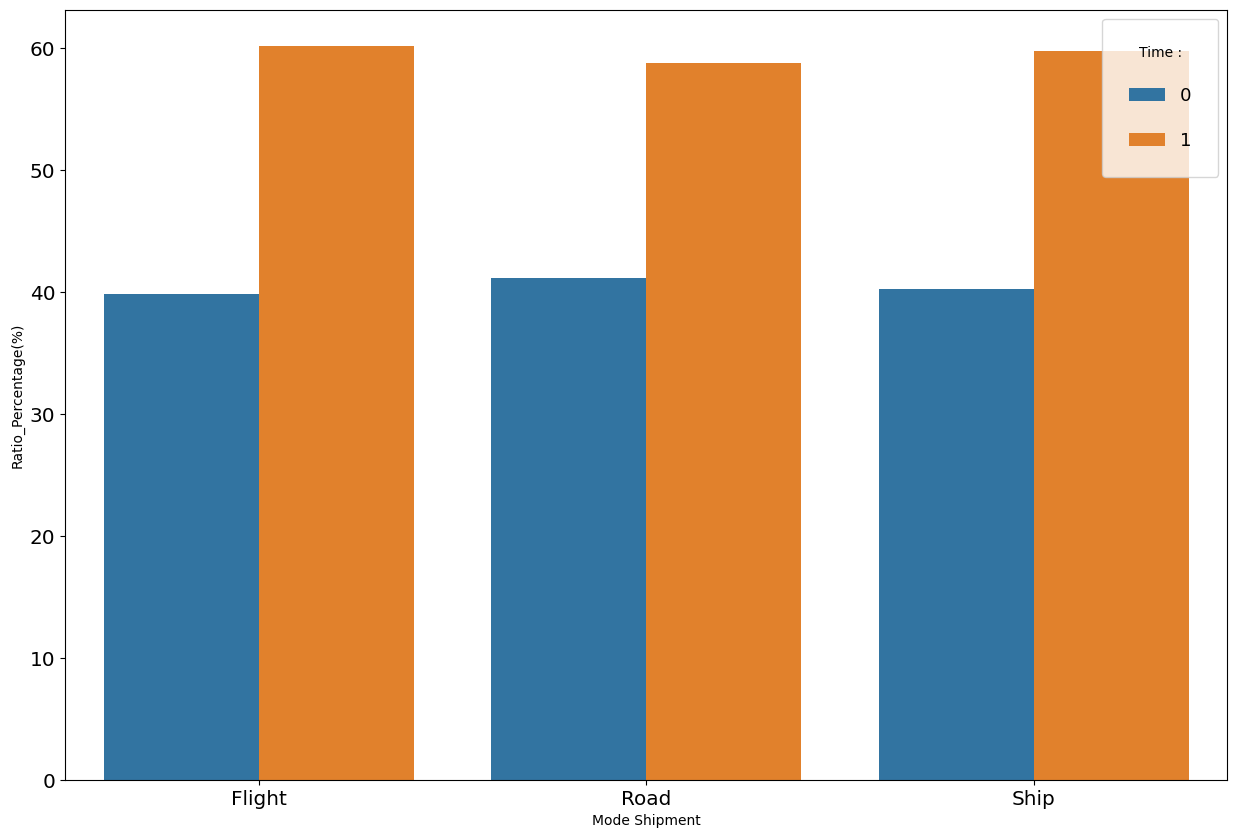

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(data=df_group5,x="Mode Shipment",y="Ratio_Percentage(%)",hue="Late")
plt.legend(loc="upper right",borderpad=1.5,labelspacing=1.5,fontsize=13,title="Time :")
plt.show()

In [ ]:
df_group11=df.groupby(["Reached.on.Time_Y.N","Product_importance"]).agg({"ID":"nunique"}).reset_index()
df_group11

,Reached.on.Time_Y.N,Product_importance,ID
0,0,high,332
1,0,low,2157
2,0,medium,1947
3,1,high,616
4,1,low,3140
5,1,medium,2807


In [ ]:
df_group12=df.groupby("Reached.on.Time_Y.N").agg({"ID":"nunique"}).reset_index()
df_group12

,Reached.on.Time_Y.N,ID
0,0,4436
1,1,6563


In [ ]:
df_group13=df_group11.merge(df_group12,on="Reached.on.Time_Y.N")
df_group13

,Reached.on.Time_Y.N,Product_importance,ID_x,ID_y
0,0,high,332,4436
1,0,low,2157,4436
2,0,medium,1947,4436
3,1,high,616,6563
4,1,low,3140,6563
5,1,medium,2807,6563


In [ ]:
df_group14=df.groupby("Product_importance").agg({"ID":"nunique"}).reset_index()
df_group14

,Product_importance,ID
0,high,948
1,low,5297
2,medium,4754


In [ ]:
df_group15=df_group11.merge(df_group14,on="Product_importance")
df_group15

,Reached.on.Time_Y.N,Product_importance,ID_x,ID_y
0,0,high,332,948
1,0,low,2157,5297
2,0,medium,1947,4754
3,1,high,616,948
4,1,low,3140,5297
5,1,medium,2807,4754


In [ ]:
df_group13["Ratio_Percentage(%)"]=df_group13["ID_x"]/df_group13["ID_y"]*100
df_group13.columns=["Late","Product Importance","UniqueCustomers","TotalUnique","Ratio_Percentage(%)"]
df_group13

,Late,Product Importance,UniqueCustomers,TotalUnique,Ratio_Percentage(%)
0,0,high,332,4436,7.484220
1,0,low,2157,4436,48.624887
2,0,medium,1947,4436,43.890893
3,1,high,616,6563,9.385952
4,1,low,3140,6563,47.843974
5,1,medium,2807,6563,42.770075


In [ ]:
df_group15["Ratio_Percentage(%)"]=df_group15["ID_x"]/df_group15["ID_y"]*100
df_group15.columns=["Late","Product Importance","UniqueCustomers","TotalUnique","Ratio_Percentage(%)"]
df_group15

,Late,Product Importance,UniqueCustomers,TotalUnique,Ratio_Percentage(%)
0,0,high,332,948,35.021097
1,0,low,2157,5297,40.721163
2,0,medium,1947,4754,40.954985
3,1,high,616,948,64.978903
4,1,low,3140,5297,59.278837
5,1,medium,2807,4754,59.045015


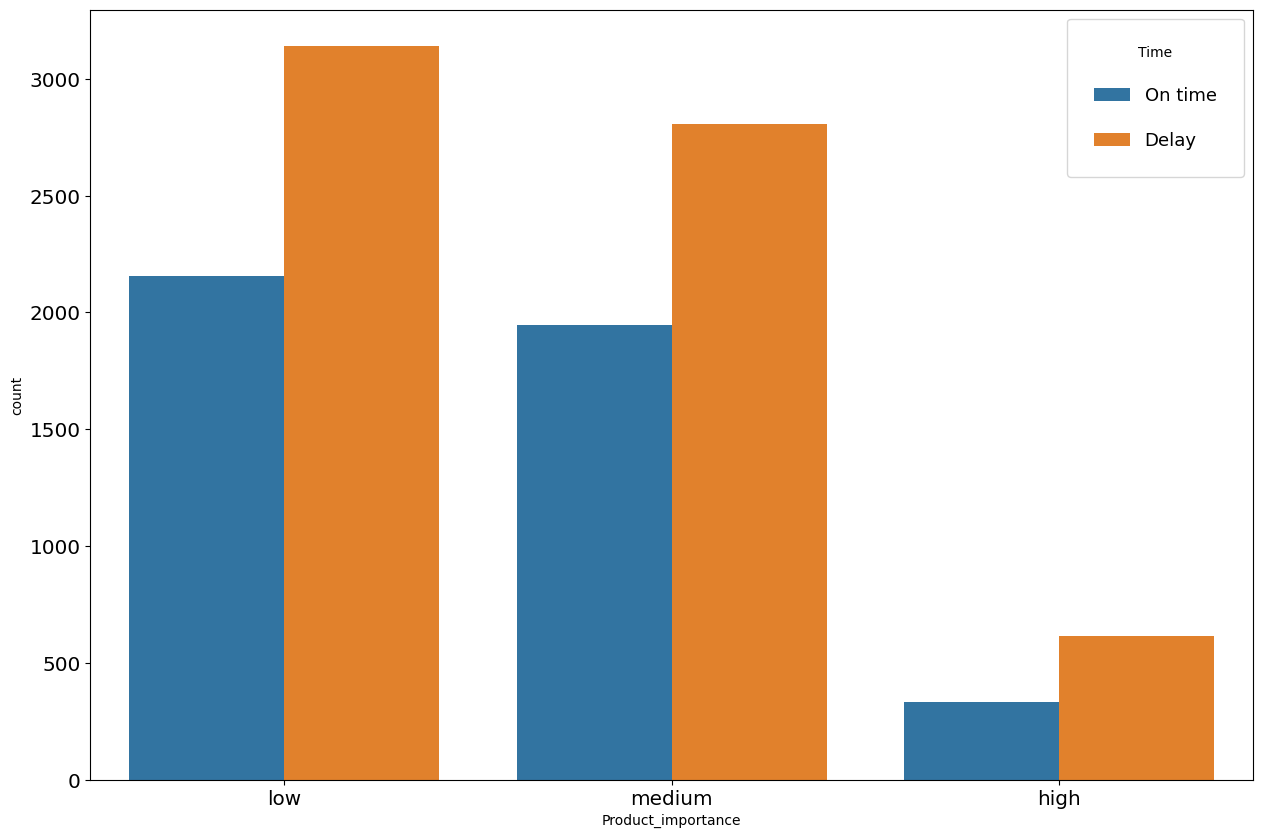

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=df,x="Product_importance",hue="Reached.on.Time_Y.N")
plt.legend(loc="upper right",borderpad=1.5,labelspacing=1.5,fontsize=13,title="Time",
          labels=["On time","Delay"])
plt.show()

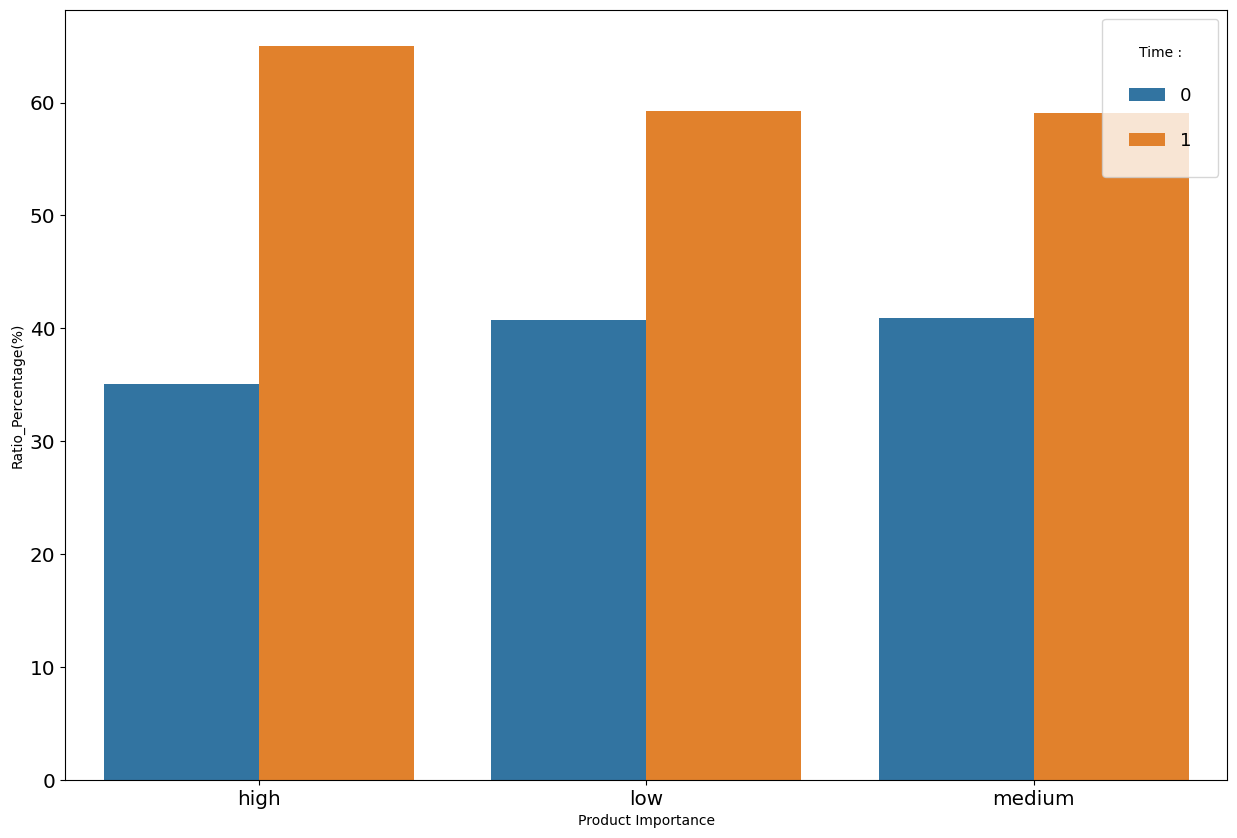

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(data=df_group15,x="Product Importance",y="Ratio_Percentage(%)",hue="Late")
plt.legend(loc="upper right",borderpad=1.5,labelspacing=1.5,fontsize=13,title="Time :")
plt.show()

In [ ]:
df_group21=df.groupby(["Reached.on.Time_Y.N","Warehouse_block"]).agg({"ID":"nunique"}).reset_index()
df_group21

,Reached.on.Time_Y.N,Warehouse_block,ID
0,0,A,758
1,0,B,729
2,0,C,739
3,0,D,738
4,0,F,1472
5,1,A,1075
6,1,B,1104
7,1,C,1094
8,1,D,1096
9,1,F,2194


In [ ]:
df_group22=df.groupby("Reached.on.Time_Y.N").agg({"ID":"nunique"}).reset_index()
df_group22

,Reached.on.Time_Y.N,ID
0,0,4436
1,1,6563


In [ ]:
df_group23=df_group21.merge(df_group22,on="Reached.on.Time_Y.N")
df_group23

,Reached.on.Time_Y.N,Warehouse_block,ID_x,ID_y
0,0,A,758,4436
1,0,B,729,4436
2,0,C,739,4436
3,0,D,738,4436
4,0,F,1472,4436
5,1,A,1075,6563
6,1,B,1104,6563
7,1,C,1094,6563
8,1,D,1096,6563
9,1,F,2194,6563


In [ ]:
df_group23["Ratio_Percentage(%)"]=df_group23["ID_x"]/df_group23["ID_y"]*100
df_group23.columns=["Late","Warehouse Block","UniqueCustomers","TotalUnique","Ratio_Percentage(%)"]
df_group23

,Late,Warehouse Block,UniqueCustomers,TotalUnique,Ratio_Percentage(%)
0,0,A,758,4436,17.087466
1,0,B,729,4436,16.433724
2,0,C,739,4436,16.659152
3,0,D,738,4436,16.636610
4,0,F,1472,4436,33.183048
5,1,A,1075,6563,16.379704
6,1,B,1104,6563,16.821575
7,1,C,1094,6563,16.669206
8,1,D,1096,6563,16.699680
9,1,F,2194,6563,33.429834


In [ ]:
df_group24=df.groupby("Warehouse_block").agg({"ID":"nunique"}).reset_index()
df_group24

,Warehouse_block,ID
0,A,1833
1,B,1833
2,C,1833
3,D,1834
4,F,3666


In [ ]:
df_group25=df_group21.merge(df_group24,on="Warehouse_block")
df_group25

,Reached.on.Time_Y.N,Warehouse_block,ID_x,ID_y
0,0,A,758,1833
1,0,B,729,1833
2,0,C,739,1833
3,0,D,738,1834
4,0,F,1472,3666
5,1,A,1075,1833
6,1,B,1104,1833
7,1,C,1094,1833
8,1,D,1096,1834
9,1,F,2194,3666


In [ ]:
df_group25["Ratio_Percentage(%)"]=df_group25["ID_x"]/df_group25["ID_y"]*100
df_group25.columns=["Late","Warehouse Block","UniqueCustomers","TotalUnique","Ratio_Percentage(%)"]
df_group25

,Late,Warehouse Block,UniqueCustomers,TotalUnique,Ratio_Percentage(%)
0,0,A,758,1833,41.352973
1,0,B,729,1833,39.770867
2,0,C,739,1833,40.316421
3,0,D,738,1834,40.239913
4,0,F,1472,3666,40.152755
5,1,A,1075,1833,58.647027
6,1,B,1104,1833,60.229133
7,1,C,1094,1833,59.683579
8,1,D,1096,1834,59.760087
9,1,F,2194,3666,59.847245


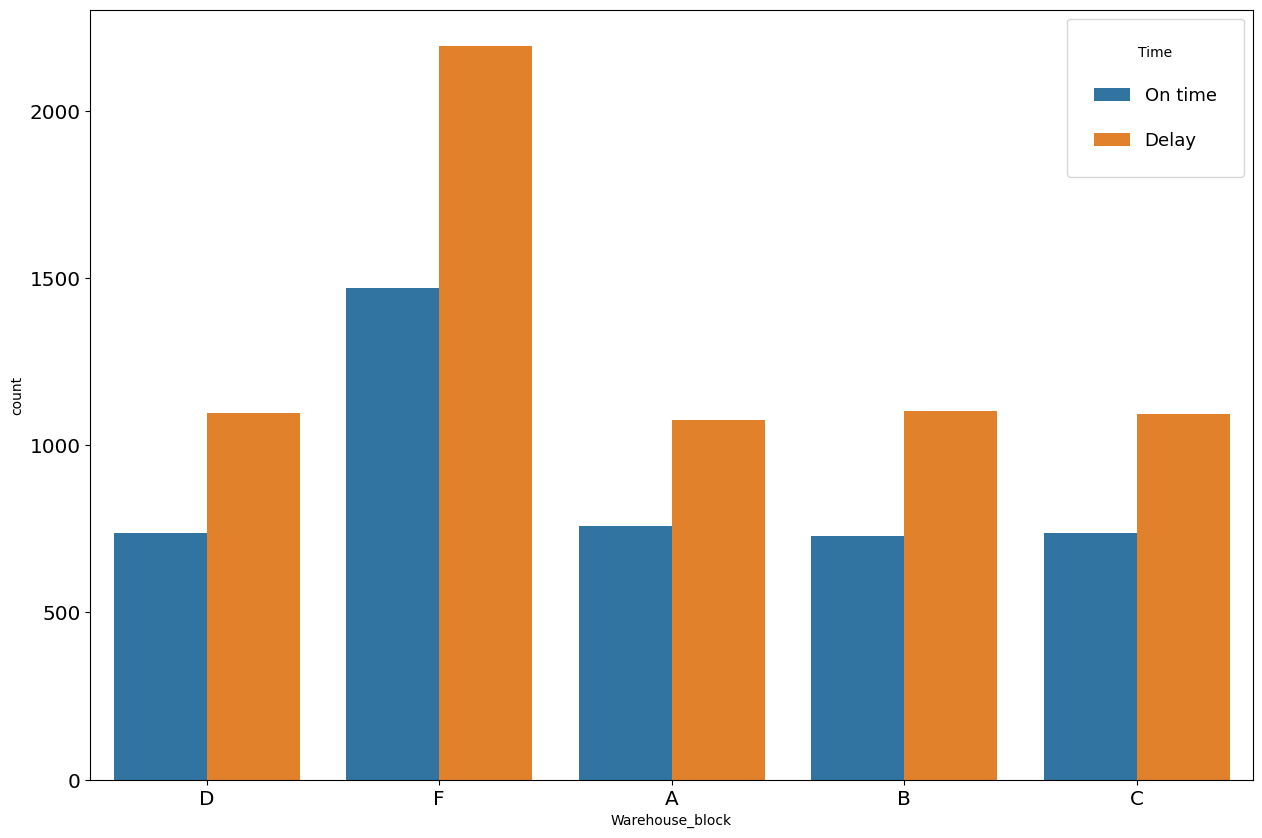

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=df,x="Warehouse_block",hue="Reached.on.Time_Y.N")
plt.legend(loc="upper right",borderpad=1.5,labelspacing=1.5,fontsize=13,title="Time",
          labels=["On time","Delay"])
plt.show()

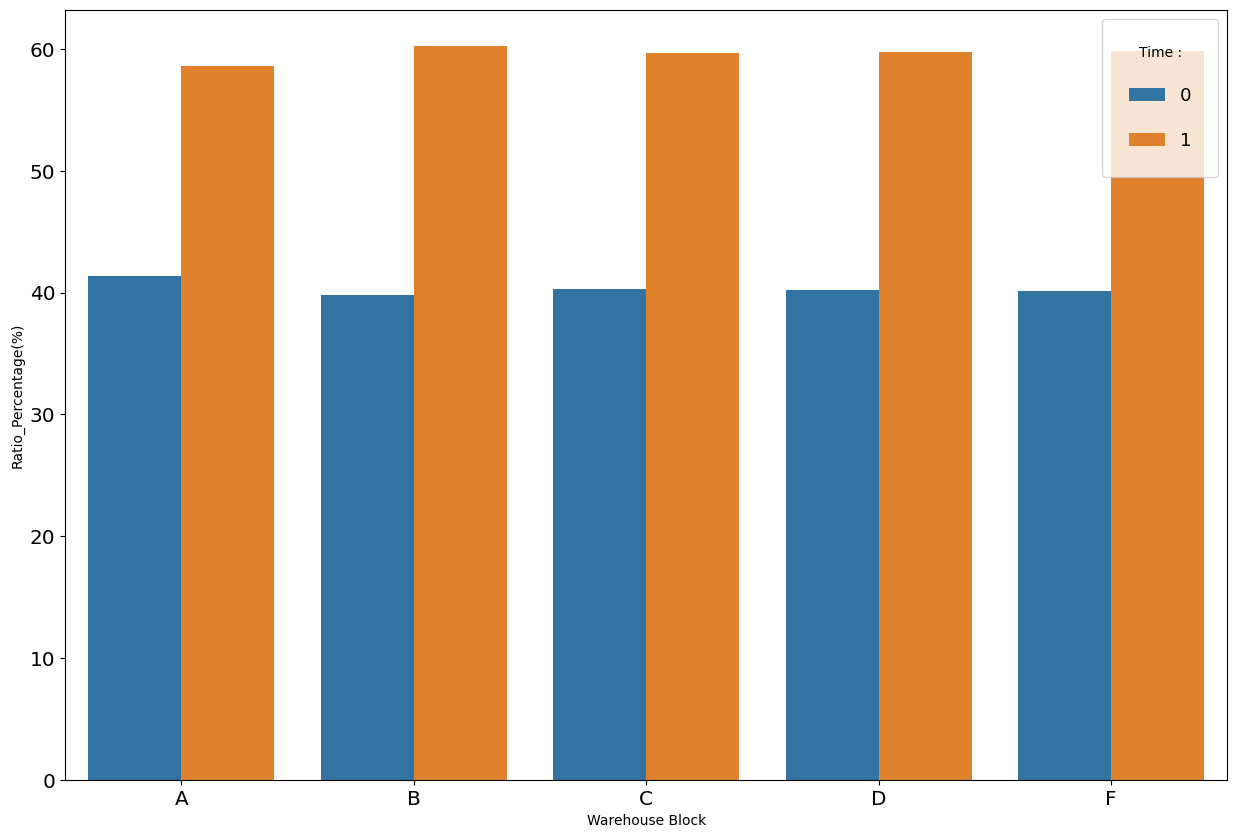

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(data=df_group25,x="Warehouse Block",y="Ratio_Percentage(%)",hue="Late")
plt.legend(loc="upper right",borderpad=1.5,labelspacing=1.5,fontsize=13,title="Time :")
plt.show()